# Customer Segmentation Analysis: BigQuery ML
This notebook pulls the final results from BigQuery to evaluate the K-means clusters and analyze **Segment Drift** between 2009 and 2011.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(dotenv_path='../.env')

client = bigquery.Client()
sns.set_theme(style="whitegrid", palette="muted")


## 1. Load Scored Data
We pull the final scored tables with business labels.

In [2]:
query_2009 = "SELECT * FROM `retail_segmentation.final_scored_2009_2010`"
df_09 = client.query(query_2009).to_dataframe()

query_2010 = "SELECT * FROM `retail_segmentation.final_scored_2010_2011`"
df_10 = client.query(query_2010).to_dataframe()

print(f"Loaded {len(df_09)} customers from 2009-2010")
print(f"Loaded {len(df_10)} customers from 2010-2011")


c:\Users\arq_c\Desktop\ds_projects\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 4285 customers from 2009-2010
Loaded 4334 customers from 2010-2011


## 2. Cluster Distribution (Year 1)
Visualizing the size of each business segment in the training period.

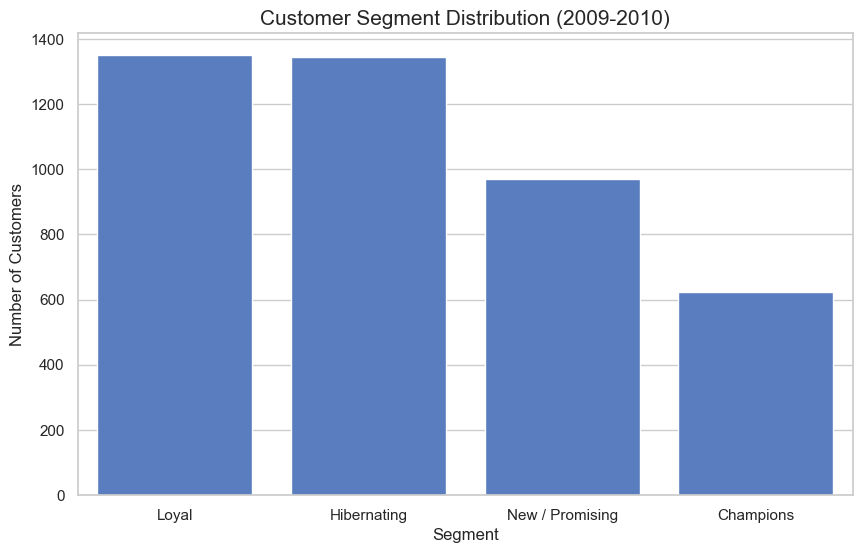

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_09, x='segment_label', order=df_09['segment_label'].value_counts().index)
plt.title('Customer Segment Distribution (2009-2010)', fontsize=15)
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.show()


## 3. Segment Drift Analysis
Comparing the percentage of customers in each segment over two years.

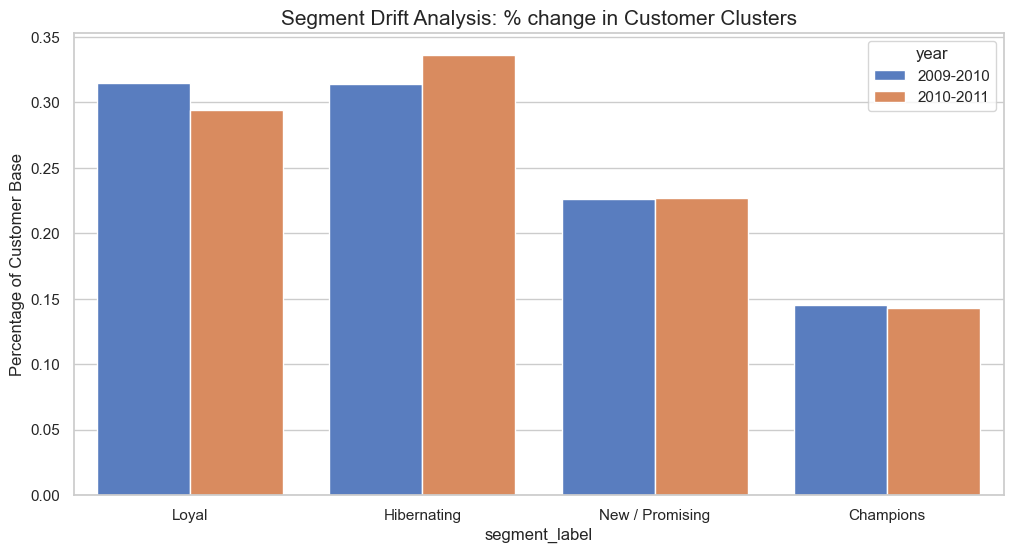

In [4]:
dist_09 = df_09['segment_label'].value_counts(normalize=True).reset_index()
dist_09.columns = ['segment_label', 'percentage']
dist_09['year'] = '2009-2010'

dist_10 = df_10['segment_label'].value_counts(normalize=True).reset_index()
dist_10.columns = ['segment_label', 'percentage']
dist_10['year'] = '2010-2011'

drift_df = pd.concat([dist_09, dist_10])

plt.figure(figsize=(12, 6))
sns.barplot(data=drift_df, x='segment_label', y='percentage', hue='year')
plt.title('Segment Drift Analysis: % change in Customer Clusters', fontsize=15)
plt.ylabel('Percentage of Customer Base')
plt.show()


## 4. RFM Feature Scattering
Visualizing the high-value 'Champions' vs others in the RFM space.

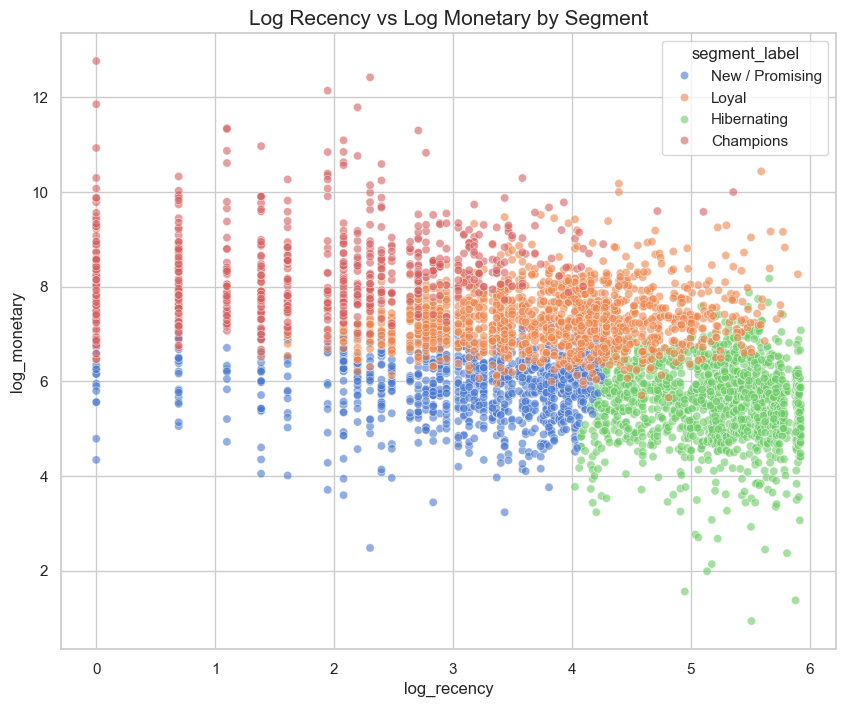

In [5]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_09, x='log_recency', y='log_monetary', hue='segment_label', alpha=0.6)
plt.title('Log Recency vs Log Monetary by Segment', fontsize=15)
plt.show()
